In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load the Iris dataset
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = iris.target_names[iris.target]

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nDescriptive statistics:")
print(df.describe())

Shape: (150, 5)

First 5 rows:
   sepal length (cm)  sepal width (cm)  ...  petal width (cm)  species
0                5.1               3.5  ...               0.2   setosa
1                4.9               3.0  ...               0.2   setosa
2                4.7               3.2  ...               0.2   setosa
3                4.6               3.1  ...               0.2   setosa
4                5.0               3.6  ...               0.2   setosa

[5 rows x 5 columns]

Descriptive statistics:
       sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
count         150.000000        150.000000         150.000000        150.000000
mean            5.843333          3.057333           3.758000          1.199333
std             0.828066          0.435866           1.765298          0.762238
min             4.300000          2.000000           1.000000          0.100000
25%             5.100000          2.800000           1.600000          0.300000
50%             

**Visualize Correlations**

Correlation matrix:
                   sepal length (cm)  ...  petal width (cm)
sepal length (cm)           1.000000  ...          0.817941
sepal width (cm)           -0.117570  ...         -0.366126
petal length (cm)           0.871754  ...          0.962865
petal width (cm)            0.817941  ...          1.000000

[4 rows x 4 columns]


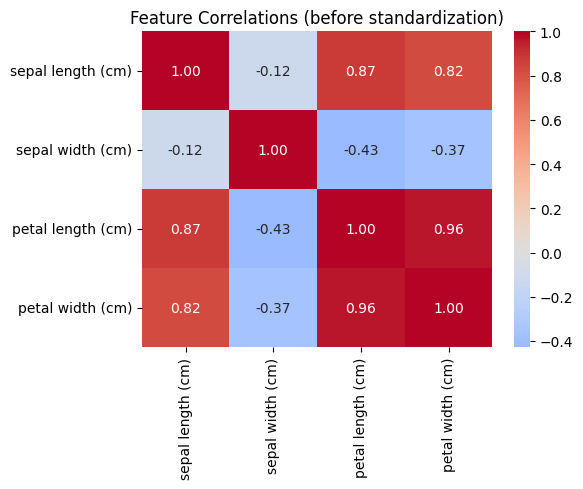

In [2]:
# Correlation matrix (numeric columns only)
corr_matrix = df.iloc[:, :4].corr()
print("Correlation matrix:")
print(corr_matrix)

# Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlations (before standardization)')
plt.tight_layout()
plt.show()

**Standardize the data**

In [3]:
# Extract numeric features
X = df.iloc[:, :4].values

# Before standardization
print("Before standardization:")
print(f"Mean per feature: {X.mean(axis=0)}")
print(f"Std per feature: {X.std(axis=0)}")

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# After standardization
print("\nAfter standardization:")
print(f"Mean per feature: {X_scaled.mean(axis=0)}")
print(f"Std per feature: {X_scaled.std(axis=0)}")

Before standardization:
Mean per feature: [5.84333333 3.05733333 3.758      1.19933333]
Std per feature: [0.82530129 0.43441097 1.75940407 0.75969263]

After standardization:
Mean per feature: [-4.73695157e-16 -7.81597009e-16 -4.26325641e-16 -4.73695157e-16]
Std per feature: [1. 1. 1. 1.]


**Fit PCA and Inspect Variance**

In [4]:
# Fit PCA with all components
pca = PCA()
pca.fit(X_scaled)

# Explained variance
print("Explained variance per component:")
print(pca.explained_variance_ratio_)

# Cumulative explained variance
cumsum_var = np.cumsum(pca.explained_variance_ratio_)
print("\nCumulative explained variance:")
for i, cum_var in enumerate(cumsum_var):
    print(f"Components 1–{i+1}: {cum_var:.4f} ({cum_var*100:.2f}%)")

Explained variance per component:
[0.72962445 0.22850762 0.03668922 0.00517871]

Cumulative explained variance:
Components 1–1: 0.7296 (72.96%)
Components 1–2: 0.9581 (95.81%)
Components 1–3: 0.9948 (99.48%)
Components 1–4: 1.0000 (100.00%)


**Scree Plot**
- Used to visulaize the explained variance

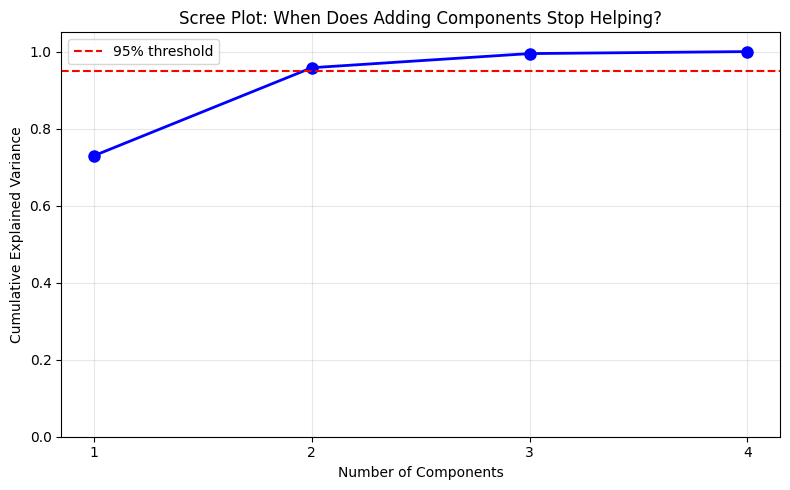

In [5]:
# Scree plot
plt.figure(figsize=(8, 5))
cumsum_var = np.cumsum(pca.explained_variance_ratio_)
plt.plot(range(1, 5), cumsum_var, 'bo-', linewidth=2, markersize=8)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% threshold')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Scree Plot: When Does Adding Components Stop Helping?')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xticks(range(1, 5))
plt.ylim([0, 1.05])
plt.tight_layout()
plt.show()

**PCA projection to 2D (based on above chart)**

[[-2.26470281  0.4800266 ]
 [-2.08096115 -0.67413356]
 [-2.36422905 -0.34190802]
 [-2.29938422 -0.59739451]
 [-2.38984217  0.64683538]
 [-2.07563095  1.48917752]
 [-2.44402884  0.0476442 ]
 [-2.23284716  0.22314807]
 [-2.33464048 -1.11532768]
 [-2.18432817 -0.46901356]
 [-2.1663101   1.04369065]
 [-2.32613087  0.13307834]
 [-2.2184509  -0.72867617]
 [-2.6331007  -0.96150673]
 [-2.1987406   1.86005711]
 [-2.26221453  2.68628449]
 [-2.2075877   1.48360936]
 [-2.19034951  0.48883832]
 [-1.898572    1.40501879]
 [-2.34336905  1.12784938]
 [-1.914323    0.40885571]
 [-2.20701284  0.92412143]
 [-2.7743447   0.45834367]
 [-1.81866953  0.08555853]
 [-2.22716331  0.13725446]
 [-1.95184633 -0.62561859]
 [-2.05115137  0.24216355]
 [-2.16857717  0.52714953]
 [-2.13956345  0.31321781]
 [-2.26526149 -0.3377319 ]
 [-2.14012214 -0.50454069]
 [-1.83159477  0.42369507]
 [-2.61494794  1.79357586]
 [-2.44617739  2.15072788]
 [-2.10997488 -0.46020184]
 [-2.2078089  -0.2061074 ]
 [-2.04514621  0.66155811]
 

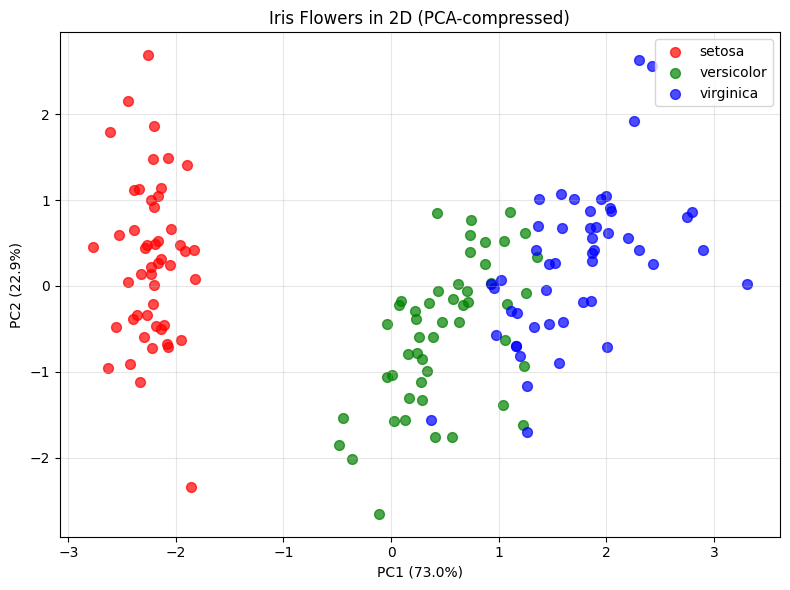

In [8]:
# Fit PCA with 2 components
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_scaled)
print(X_pca)

print(f"Original shape: {X_scaled.shape}")
print(f"After PCA shape: {X_pca.shape}")
print(f"\nExplained variance with 2 components: {pca_2d.explained_variance_ratio_.sum():.4f}")

# Scatter plot
plt.figure(figsize=(8, 6))
species_colors = {'setosa': 'red', 'versicolor': 'green', 'virginica': 'blue'}
for species in df['species'].unique():
    mask = df['species'] == species
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                label=species, alpha=0.7, s=50, 
                color=species_colors[species])

plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('Iris Flowers in 2D (PCA-compressed)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Manual EigenDecomposition**

In [7]:
# Manual PCA: eigendecomposition
cov_matrix = np.cov(X_scaled.T)
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Sort by eigenvalue (descending)
idx = eigenvalues.argsort()[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# Explained variance ratio
explained_var = eigenvalues / eigenvalues.sum()
print("Manual eigendecomposition:")
print(f"Explained variance ratio: {explained_var}")
print(f"\nThis matches sklearn's output: {pca.explained_variance_ratio_}")

# Project using manual eigenvectors
X_pca_manual = X_scaled @ eigenvectors[:, :2]
print(f"\nManual projection matches sklearn: {np.allclose(X_pca, X_pca_manual)}")

Manual eigendecomposition:
Explained variance ratio: [0.72962445 0.22850762 0.03668922 0.00517871]

This matches sklearn's output: [0.72962445 0.22850762 0.03668922 0.00517871]

Manual projection matches sklearn: False


In [11]:
print(f"Manual PCA: {X_pca_manual[:5]}")  # Show first 5 rows for brevity
print(f"Scikit-learn PCA: {X_pca[:5]}")  # Show first 5 rows for brevity

Manual PCA: [[-2.26470281 -0.4800266 ]
 [-2.08096115  0.67413356]
 [-2.36422905  0.34190802]
 [-2.29938422  0.59739451]
 [-2.38984217 -0.64683538]]
Scikit-learn PCA: [[-2.26470281  0.4800266 ]
 [-2.08096115 -0.67413356]
 [-2.36422905 -0.34190802]
 [-2.29938422 -0.59739451]
 [-2.38984217  0.64683538]]
